In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 4             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 250
    target_sample_size = 16
    nrepp = 1
    
    # Set the random seed for reproducibility
    torch.manual_seed(42)
    
    n = 50
    p = 4
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    eval_dataset = SimulatedDataset(1000, p, maxlen=4, device = device).data
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask_pairwise = create_custom_mask_pair(maxlen, device)
    mask_pred = create_custom_mask_pred(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise,mask_pred, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  50 

Number of Parameters 82
EPOCH 1:
avg_loss: 8.58665
EPOCH 11:
avg_loss: 3.34576
EPOCH 21:
avg_loss: 3.32727
EPOCH 31:
avg_loss: 3.30083
EPOCH 41:
avg_loss: 3.27779
EPOCH 51:
avg_loss: 3.25753
EPOCH 61:
avg_loss: 3.24017
EPOCH 71:
avg_loss: 3.22470
EPOCH 81:
avg_loss: 3.20635
EPOCH 91:
avg_loss: 3.18612
EPOCH 101:
avg_loss: 3.16948
EPOCH 111:
avg_loss: 3.15486
EPOCH 121:
avg_loss: 3.13735
EPOCH 131:
avg_loss: 3.11284
EPOCH 141:
avg_loss: 3.10270
EPOCH 151:
avg_loss: 3.08090
EPOCH 161:
avg_loss: 3.06242
EPOCH 171:
avg_loss: 3.04899
EPOCH 181:
avg_loss: 3.03978
EPOCH 191:
avg_loss: 3.01423
EPOCH 201:
avg_loss: 3.00464
EPOCH 211:
avg_loss: 2.99097
EPOCH 221:
avg_loss: 2.96446
EPOCH 231:
avg_loss: 2.94332
EPOCH 241:
avg_loss: 2.92676
Execution time: 8.866633 seconds


In [ ]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/1
Processed 10000000 combinations out of approximately 4294967296
Processed 20000000 combinations out of approximately 4294967296
Processed 30000000 combinations out of approximately 4294967296
Processed 40000000 combinations out of approximately 4294967296
Processed 50000000 combinations out of approximately 4294967296
Processed 60000000 combinations out of approximately 4294967296
Processed 70000000 combinations out of approximately 4294967296
Processed 80000000 combinations out of approximately 4294967296
Processed 90000000 combinations out of approximately 4294967296
Processed 100000000 combinations out of approximately 4294967296
Processed 110000000 combinations out of approximately 4294967296
Processed 120000000 combinations out of approximately 4294967296
Processed 130000000 combinations out of approximately 4294967296
Processed 140000000 combinations out of approximately 4294967296
Processed 150000000 combinations out of approximately 4294967296
Processed 160000000

In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.0000 ± 0.00
Variable 2: 0.0010 ± 0.00
Variable 3: 0.0371 ± 0.00
Variable 4: 0.7766 ± 0.00


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/1


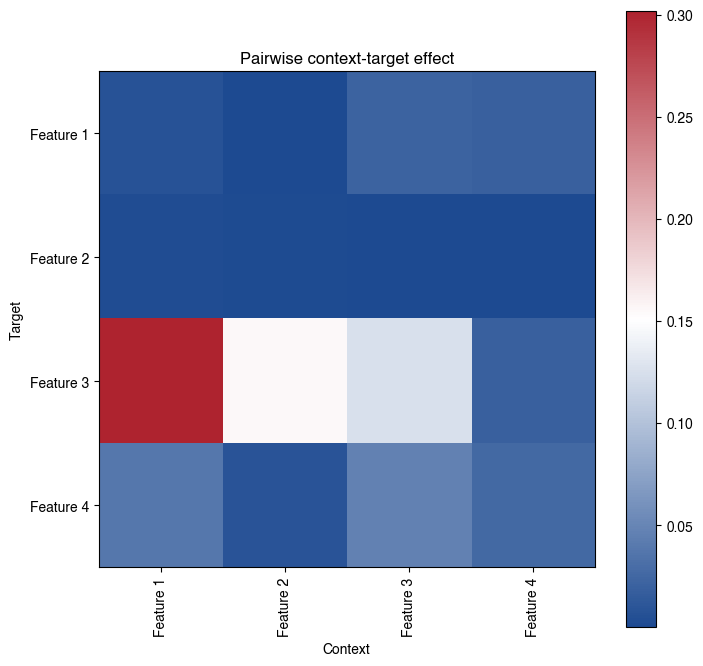

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, run_path)

In [ ]:
with open(f"./notebooks/statistical_testing/{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}.txt", "a") as f:
    f.write("For combination sample size: all (exact) \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    